## Frequentist vs Bayesian background comparison

Smushes results from `Background_fit.ipynb` (Bayesian posteriors) and `likelihood.ipynb`
(frequentist MLE) to compare all three approaches as probability distributions on the same axis. 
Basically answering the spectrum graph question, honestly unsure if this is what was meant.

In [5]:
import sys; sys.path.insert(0, '..')
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.integrate import trapezoid
from scipy.optimize import minimize_scalar

from src.loader import k_obs, b_nominal, roi_mask

In [6]:
# ── Shared quantities (mirrors Background_fit.ipynb) ─────────────────────────
# roi_mask is imported from loader, same as in Background_fit.ipynb
K_tot = np.sum(k_obs[roi_mask])
B_tot = np.sum(b_nominal.values[roi_mask])

beta_range = np.linspace(0.1, 30, 1000)

In [7]:
# ── Scale-invariant prior: π(β) ∝ 1/β (Background_fit.ipynb, first prior) ───
# Log-posterior: (K_tot - 1)*log(β) - β*B_tot  (the -1 comes from log(1/β) = -log(β))
def log_posterior_scale_invariant(beta):
    return (K_tot - 1) * np.log(beta) - beta * B_tot

log_post_si   = log_posterior_scale_invariant(beta_range)
post_si_unnorm = np.exp(log_post_si - log_post_si.max())  # stabilise exp
evidence_si   = trapezoid(post_si_unnorm, beta_range)
post_si       = post_si_unnorm / evidence_si

mean_si = trapezoid(beta_range * post_si, beta_range)
cdf_si  = np.cumsum(post_si) * (beta_range[1] - beta_range[0])
lo_si   = beta_range[np.searchsorted(cdf_si, 0.16)]
hi_si   = beta_range[np.searchsorted(cdf_si, 0.84)]

print(f"Scale-invariant prior — Mean β: {mean_si:.4f},  68% CI: [{lo_si:.4f}, {hi_si:.4f}]")

Scale-invariant prior — Mean β: 7.5887,  68% CI: [5.7268, 9.4681]


In [8]:
# ── Flat prior: π(β) = const (Background_fit.ipynb, second prior) ────────────
beta_min, beta_max = 0.1, 30.0
prior_flat = 1.0 / (beta_max - beta_min)  # same as in Background_fit.ipynb

# Log-posterior: K_tot*log(β) - β*B_tot + log(prior_flat)
def log_posterior_flat(beta):
    return K_tot * np.log(beta) - beta * B_tot + np.log(prior_flat)

log_post_fl    = log_posterior_flat(beta_range)
post_fl_unnorm = np.exp(log_post_fl - log_post_fl.max())  # stabilise exp
evidence_fl    = trapezoid(post_fl_unnorm, beta_range)
post_fl        = post_fl_unnorm / evidence_fl

mean_fl = trapezoid(beta_range * post_fl, beta_range)
cdf_fl  = np.cumsum(post_fl) * (beta_range[1] - beta_range[0])
lo_fl   = beta_range[np.searchsorted(cdf_fl, 0.16)]
hi_fl   = beta_range[np.searchsorted(cdf_fl, 0.84)]

print(f"Flat prior            — Mean β: {mean_fl:.4f},  68% CI: [{lo_fl:.4f}, {hi_fl:.4f}]")

Flat prior            — Mean β: 8.0630,  68% CI: [6.1458, 9.9769]


In [9]:
# ── Frequentist MLE + curvature uncertainty (likelihood.ipynb) ────────────────
# Redefine the negative log-likelihood over the ROI, same as in likelihood.ipynb
def log_likelihood_bg_only(beta):
    expected = beta * b_nominal.values[roi_mask]
    return -np.sum(stats.poisson.logpmf(k_obs[roi_mask], expected))

result   = minimize_scalar(log_likelihood_bg_only, bounds=(0.1, 30.0), method='bounded')
beta_hat = result.x

# Curvature: σ_β ≈ sqrt(1 / d²(-lnL)/dβ²) evaluated at β_hat (likelihood.ipynb)
h          = 1e-4
d2         = (log_likelihood_bg_only(beta_hat + h) - 2*log_likelihood_bg_only(beta_hat)
              + log_likelihood_bg_only(beta_hat - h)) / h**2
sigma_beta = np.sqrt(1.0 / d2)

# Laplace approximation: treat the curvature Gaussian as a density
laplace = stats.norm.pdf(beta_range, loc=beta_hat, scale=sigma_beta)

print(f"Frequentist           — β̂: {beta_hat:.4f} ± {sigma_beta:.4f}")

Frequentist           — β̂: 7.5887 ± 1.8972


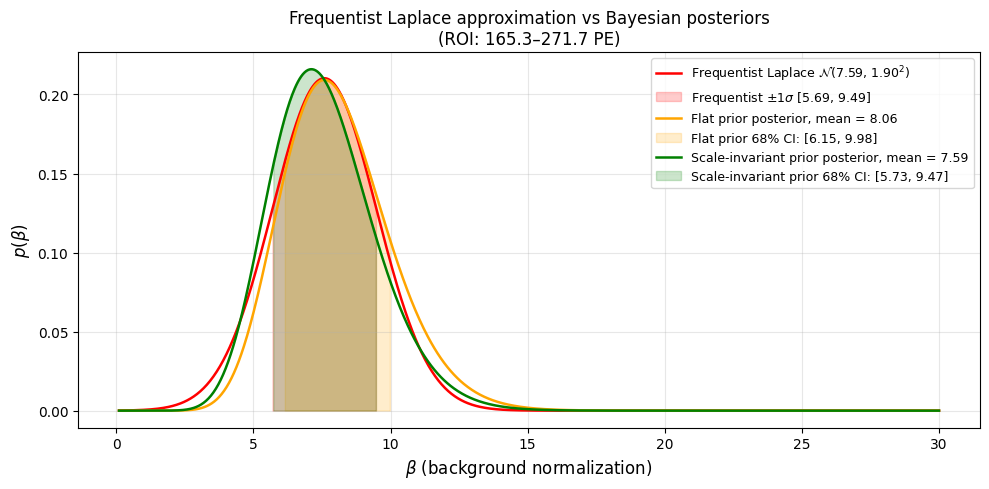

In [10]:
# ── Comparison: all three as probability densities ────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# Frequentist Laplace approximation
ax.plot(beta_range, laplace, color='red', linewidth=1.8,
        label=rf'Frequentist Laplace $\mathcal{{N}}({beta_hat:.2f},\,{sigma_beta:.2f}^2)$')
ax.fill_between(beta_range, laplace,
                where=(beta_range >= beta_hat - sigma_beta) & (beta_range <= beta_hat + sigma_beta),
                alpha=0.2, color='red', label=rf'Frequentist $\pm1\sigma$ [{beta_hat - sigma_beta:.2f}, {beta_hat + sigma_beta:.2f}]')

# Bayesian: flat prior
ax.plot(beta_range, post_fl, color='orange', linewidth=1.8,
        label=rf'Flat prior posterior, mean = {mean_fl:.2f}')
ax.fill_between(beta_range, post_fl,
                where=(beta_range >= lo_fl) & (beta_range <= hi_fl),
                alpha=0.2, color='orange', label=f'Flat prior 68% CI: [{lo_fl:.2f}, {hi_fl:.2f}]')

# Bayesian: scale-invariant prior
ax.plot(beta_range, post_si, color='green', linewidth=1.8,
        label=rf'Scale-invariant prior posterior, mean = {mean_si:.2f}')
ax.fill_between(beta_range, post_si,
                where=(beta_range >= lo_si) & (beta_range <= hi_si),
                alpha=0.2, color='green', label=f'Scale-invariant prior 68% CI: [{lo_si:.2f}, {hi_si:.2f}]')

ax.set_xlabel(r'$\beta$ (background normalization)', fontsize=12)
ax.set_ylabel(r'$p(\beta)$', fontsize=12)
ax.set_title('Frequentist Laplace approximation vs Bayesian posteriors\n(ROI: 165.3–271.7 PE)', fontsize=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/frequentist_vs_bayesian_density.png', dpi=150, bbox_inches='tight')
plt.show()